# Week 1 - Classical Prep ReAct Graph

1주차 미션용 클래식 공연 예습 ReAct 그래프를 실행해보고, 그래프 그림과 테스트 질문 결과를 확인합니다.

In [1]:
from pathlib import Path
import sys

cwd = Path.cwd()
candidates = [
    cwd,
    cwd / "assignments" / "daexvk" / "week1",
    cwd / "week1",
]

target_dir = next(path for path in candidates if (path / "graph.py").exists())
sys.path.insert(0, str(target_dir.resolve()))

print("target_dir:", target_dir.resolve())


target_dir: /Users/nozerose/Documents/GitHub/rag-agent-study/assignments/daexvk/week1


## Graph

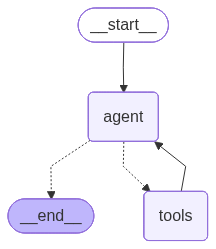

Graph image saved to: /Users/nozerose/Documents/GitHub/rag-agent-study/assignments/daexvk/week1/classical_prep_graph.png


In [ ]:
from pathlib import Path
from IPython.display import Image, Markdown, display
from graph import graph

output_dir = Path(".")
png_path = output_dir / "graph.png"
mermaid_path = output_dir / "graph.mmd"

try:
    png = graph.get_graph().draw_mermaid_png()
    png_path.write_bytes(png)
    display(Image(png))
    print(f"Graph image saved to: {png_path.resolve()}")
except Exception as exc:
    print("PNG rendering failed, saving Mermaid instead:", exc)
    mermaid = graph.get_graph().draw_mermaid()
    mermaid_path.write_text(mermaid, encoding="utf-8")
    display(Markdown("```mermaid\n" + mermaid + "\n```"))
    print(f"Mermaid graph saved to: {mermaid_path.resolve()}")


## Ask Directly


In [4]:
from langchain_core.messages import HumanMessage


def ask_classical_prep(question: str):
    result = graph.invoke(
        {
            "messages": [HumanMessage(content=question)],
            "used_tools": [],
            "final_answer": None,
        },
        config={"recursion_limit": 12},
    )
    return result


def print_prep_result(result):
    answer = result.get("final_answer")
    used_tools = result.get("used_tools", [])

    print("Used tools:", ", ".join(used_tools) if used_tools else "None")

    if answer is None:
        print(result["messages"][-1].content)
        return

    if answer.concert_title:
        print("공연:", answer.concert_title)
    if answer.concert_date:
        print("일시:", answer.concert_date)
    if answer.venue:
        print("장소:", answer.venue)
    if answer.performers:
        print("연주자:", ", ".join(answer.performers))

    print("작품:", answer.work_title)
    if answer.composer:
        print("작곡가:", answer.composer)
    print("난이도:", answer.difficulty)
    print("\n요약")
    print(answer.summary)

    sections = [
        ("프로그램", answer.program_works),
        ("배경", answer.background),
        ("감상 포인트", answer.listening_points),
        ("공연 전 준비", answer.recommended_before_concert),
        ("예습 검색어", answer.preview_keywords),
        ("출처", answer.sources),
    ]

    for title, items in sections:
        if items:
            print(f"\n{title}")
            for item in items:
                print(f"- {item}")


## Try A Question


In [5]:
question = "말러 교향곡 5번 공연 전에 예습하고 싶어. 처음 듣는 사람 기준으로 알려줘."

result = ask_classical_prep(question)
print_prep_result(result)

Used tools: retrieve_work_overview, retrieve_creation_background, retrieve_concert_listening_points, retrieve_preview_keywords
작품: 말러 교향곡 5번
작곡가: 구스타프 말러
난이도: beginner

요약
말러 교향곡 5번은 ‘어둡게 시작해, 갈등을 지나, 마지막에 더 밝고 복잡한 에너지로 나아가는’ 아주 큰 규모의 교향곡입니다. 처음 듣는다면 줄거리를 따라가려 하기보다, 각 악장의 분위기 변화와 대표적인 순간(장례 행진 같은 시작, 유명한 아다지에토, 활기찬 마지막 악장)을 잡아 듣는 것이 좋습니다.

프로그램
- 말러 교향곡 5번

배경
- 말러의 중기 대표작으로, 성악 없이 오케스트라만으로 구성된 교향곡입니다.
- 작곡 시기는 1901~1902년으로 알려져 있으며, 말러의 개인적 위기와 회복, 그리고 알마와의 만남 같은 시기와 자주 연결해 설명됩니다.
- 다만 각 악장을 하나의 이야기로 딱 고정해 해석하는 것은 조심해야 합니다. 말러 음악은 감정과 구조가 복합적으로 얽혀 있습니다.
- 특히 4악장 ‘아다지에토’는 말러 교향곡 중 가장 널리 사랑받는 부분 중 하나입니다.

감상 포인트
- 1악장: 트럼펫 신호처럼 시작하는 분위기와 장례 행진 리듬을 들어보세요. '출발부터 긴장감이 있다'는 점이 핵심입니다.
- 2악장: 더 격렬하고 폭발적인 에너지가 강합니다. 앞 악장보다 거칠고 밀어붙이는 느낌이 있습니다.
- 3악장: 왈츠 같은 움직임이 섞이지만, 단순히 밝기만 하진 않습니다. 춤추는 듯하면서도 불안정한 느낌을 들어보세요.
- 4악장 아다지에토: 현악기와 하프의 부드럽고 고요한 소리가 중심입니다. 공연장에서 가장 길게 숨 고르듯 듣기 좋은 악장입니다.
- 5악장: 밝아지는 듯 시작하지만 복잡한 에너지와 추진력이 강합니다. 마지막에 모든 악기가 몰아치는 흐름을 느껴보세요.

공연 전 준비
- 아다지에토만 따로 먼저 들어보고, 그다음 전체 5악장을 훑어보면 부

In [6]:
question = "https://classicbusan.busan.go.kr/product/ko/performance/253166"

result = ask_classical_prep(question)
print_prep_result(result)

Used tools: fetch_concert_page, extract_concert_program, retrieve_work_overview, retrieve_creation_background, retrieve_concert_listening_points, retrieve_preview_keywords
공연: 부산오페라하우스 야외오페라 <카르멘>
장소: 부산콘서트홀
작품: 카르멘 (Carmen)
작곡가: 조르주 비제 (Georges Bizet)
난이도: beginner

요약
《카르멘》은 자유분방한 집시 여성 카르멘과 그녀에게 매혹된 남자 돈 호세의 비극적인 관계를 그린 대표 오페라입니다. 멜로디가 매우 귀에 잘 들어오고, 유명한 아리아와 합창이 많아 오페라 초보자도 즐기기 좋습니다.

프로그램
- 카르멘

배경
- 조르주 비제의 오페라로, 1875년 파리에서 초연되었습니다.
- 초연 당시에는 다소 충격적이고 파격적인 작품으로 받아들여졌지만, 이후 세계에서 가장 사랑받는 오페라 중 하나가 되었습니다.
- 원작은 프랑스 작가 메리메의 소설 『카르멘』입니다.
- 스페인을 배경으로 하지만, 작곡은 프랑스에서 이루어졌고 ‘이국적인 분위기’가 강하게 느껴집니다.

감상 포인트
- 가장 유명한 멜로디들: ‘하바네라’, ‘투우사의 노래’, ‘세기디야’ 같은 아리아가 나올 때 귀를 열어두면 좋습니다.
- 카르멘의 음악은 당당하고 유혹적인 느낌, 돈 호세의 음악은 점점 흔들리고 불안해지는 느낌으로 대비됩니다.
- 합창 장면에서는 무대 전체의 분위기와 군중의 에너지가 크게 살아납니다.
- 오페라는 줄거리보다도 인물의 감정 변화가 음악으로 어떻게 드러나는지에 집중하면 더 잘 들립니다.
- 야외오페라라면 바람, 거리 소음, 공간의 울림까지 포함해 ‘현장감’이 감상 포인트가 될 수 있습니다.

공연 전 준비
- 줄거리 요약을 5분 정도만 읽고 가기
- 대표 아리아 2~3곡만 미리 들어보기
- 카르멘, 돈 호세, 에스카미요의 관계를 간단히 정리해두기
- 자막이 있다면 ‘누가 누구를

In [7]:
question = "클래식 처음보는데 주의할 점이 있을까 ?"

result = ask_classical_prep(question)
print_prep_result(result)

Used tools: None
작품: 클래식 공연 첫 관람 시 주의할 점
난이도: beginner

요약
처음 클래식 공연을 볼 때는 ‘정답을 맞히는 것’보다 조용히 집중해서 듣고, 박수 타이밍과 기본 예절만 지키면 충분합니다.

배경
- 클래식 공연은 관객이 함께 집중해서 음악의 흐름을 따라가는 자리라서, 작은 소리도 크게 느껴질 수 있습니다.
- 공연마다 분위기가 조금씩 달라서, 프로그램북이나 안내문에 적힌 예절을 먼저 확인하면 안전합니다.

감상 포인트
- 곡의 시작과 끝, 분위기가 바뀌는 지점을 느껴보세요.
- 멜로디가 반복되거나 커지는 부분이 있으면 귀를 조금 더 집중해보세요.
- 솔로 악기나 특정 악기가 튀어나오는 순간을 찾아보면 더 재미있습니다.

공연 전 준비
- 휴대폰은 무음으로 바꾸기
- 공연 중에는 대화, 봉투 소리, 과자봉지 소리 줄이기
- 박수는 보통 곡이 완전히 끝난 뒤 치기
- 늦게 도착하면 입장 안내를 따르기
- 기침이 나올 것 같으면 미리 물 한 모금 마시고, 최대한 조용히 하기
- 악장 사이 박수는 공연장 분위기를 보고 따라가기

예습 검색어
- 클래식 공연 예절
- 클래식 초보 관람 팁
- 클래식 박수 타이밍

출처
- 일반 공연 관람 예절 안내
